In [1]:
# Importing Required Libraries  
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sns

# Loading the Dataset 
df=pd.read_csv("Project_Resources/train.csv",index_col="Row_ID")

# Data Cleanup
df["Postal_Code"]=df["Postal_Code"].fillna(0)
df["Postal_Code"]=df["Postal_Code"].astype(int)
df=df.convert_dtypes()
l=["Order_Date","Ship_Date"]
for i in l:
    df[i]=pd.to_datetime(df[i],format="%d-%m-%Y")

# Expolratory Data Analaysis

In [2]:
df_plot=df["Sub-Category"].value_counts().head(10).to_frame()

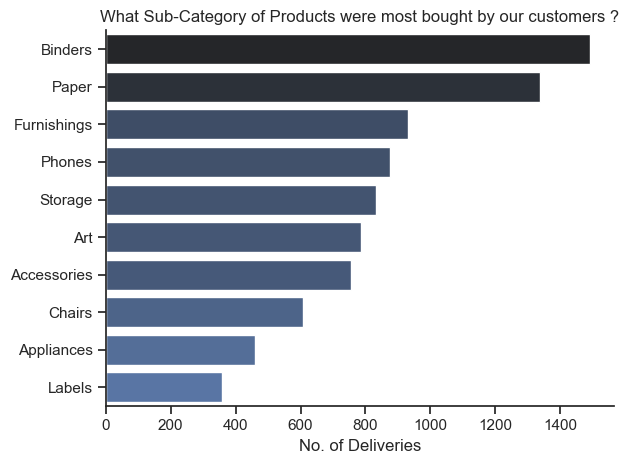

In [6]:
sns.barplot(data=df_plot, x="count", y="Sub-Category", hue="count", palette="dark:b_r", legend=False)
sns.set_theme(style="ticks")
sns.despine()
mp.title("What Sub-Category of Products were most bought by our customers ?")
mp.ylabel("")
mp.xlabel("No. of Deliveries")
mp.tight_layout()
mp.show()

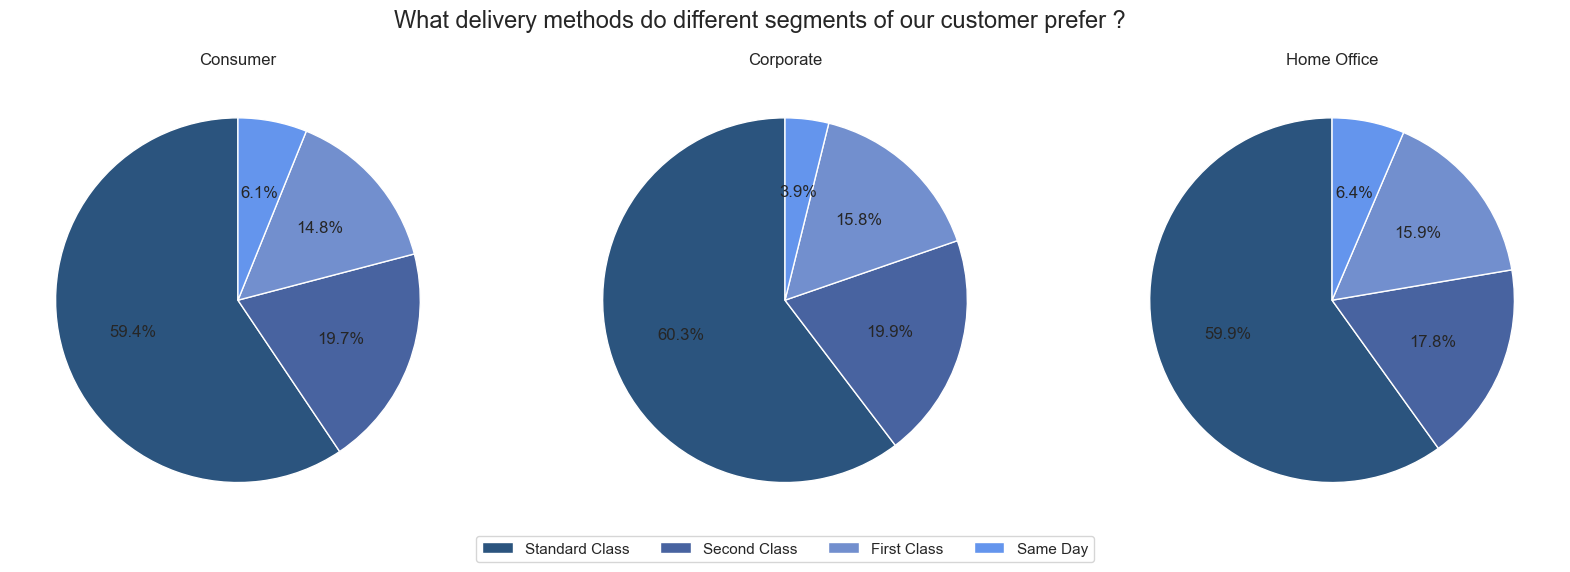

In [4]:
fig, ax=mp.subplots(1,3)
df_list=df["Segment"].unique()
custom_colors=["#2B547E", "#4863A0", "#728FCE", "#6495ED"]
for i, l in enumerate(df_list):
   ax[i].pie(df[df["Segment"]==l].Ship_Mode.value_counts(), startangle=90, autopct="%1.1f%%", colors=custom_colors)
   ax[i].set_title(l)
labels=df[df["Segment"]==l].Ship_Mode.value_counts().keys()
fig.suptitle("What delivery methods do different segments of our customer prefer ?", fontsize=17)
fig.set_size_inches(20,6)
mp.legend(labels, loc="upper center", bbox_to_anchor=(-0.7,0.0), ncol=4)
mp.show()

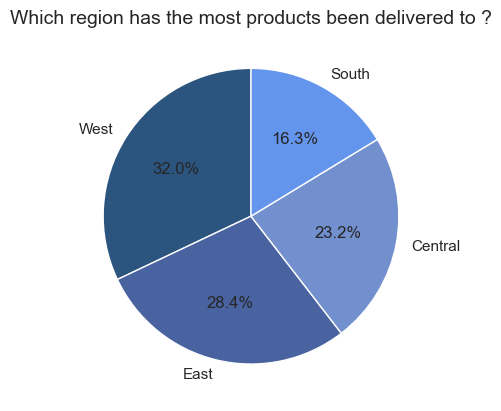

In [5]:
lab=df["Region"].value_counts().keys()
custom_colors_1=["#2B547E", "#4863A0", "#728FCE", "#6495ED"]
mp.title("Which region has the most products been delivered to ?", fontsize=14)
fig=mp.gcf()
mp.pie(df["Region"].value_counts(),startangle=90, autopct="%1.1f%%", labels=lab, colors=custom_colors_1)
mp.show()